
Собираем пазл: su_fighter_shuffle
Пазл успешно собран
Изображение сохранено: restored_photo\su_fighter_restored.jpg


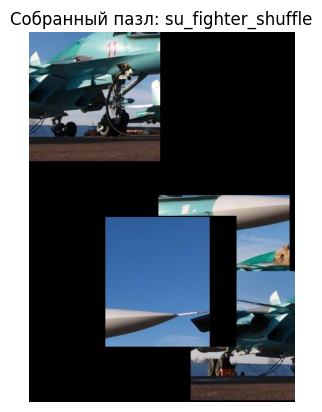


Собираем пазл: china_shuffle
Не найдены изображения в папке puzzle\china_shuffle

Собираем пазл: home_shuffle
Не найдены изображения в папке puzzle\home_shuffle


In [ ]:
import cv2
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

def apply_transformation(transform_mat, points):
    transformed_points = (transform_mat @ points.T).T
    transformed_points = np.divide(transformed_points.T, transformed_points[:, 2]).T
    return transformed_points

def construct_offset_transformation(x):
    transformation = np.eye(3)
    transformation[:2, 2] = x
    return transformation

def find_offset_ransac(points, transformed_points):
    best_offset = None
    best_loss = np.inf
    loss_f = lambda x1, x2: np.linalg.norm(x1 - x2)
    for point, transformed_point in zip(points, transformed_points):
        offset = (transformed_point - point)[:2]
        transformation = construct_offset_transformation(offset)
        tmp = apply_transformation(transformation, points)
        tmp_loss = loss_f(tmp, transformed_points)
        if tmp_loss < best_loss:
            best_loss = tmp_loss
            best_offset = offset
    return best_offset

def get_shift(first, second):
    nfetures = first.size // second.size * 200

    hyp_params2 = dict(
        nfeatures=200,
        nOctaveLayers=3,
        contrastThreshold=0.03,
        edgeThreshold=10,
        sigma=1.6
    ) 

    hyp_params1 = dict(
        nfeatures=nfetures,
        nOctaveLayers=3,
        contrastThreshold=0.03,
        edgeThreshold=10,
        sigma=1.6
    ) 
    
    sift2 = cv2.SIFT_create(**hyp_params2)
    sift1 = cv2.SIFT_create(**hyp_params1)
    
    FLANN_INDEX_KDTREE = 2
    index_params = dict(algorithm=2, trees=15)
    search_params = dict(checks=150)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    kp1, des1 = sift1.detectAndCompute(first, None)
    kp2, des2 = sift2.detectAndCompute(second, None)

    if des2 is None or des1 is None:
        return None
    
    try:
        matches = flann.knnMatch(des1, des2, k=2)
        ratio_thresh = 0.4
        good_matches = []
        for m, n in matches:
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    except:
        return None
        
    if len(good_matches) == 0:
        return None
        
    points = np.array([[kp1[m.queryIdx].pt[1], kp1[m.queryIdx].pt[0], 1] for m in good_matches])
    transformed_points = np.array([[kp2[m.trainIdx].pt[1], kp2[m.trainIdx].pt[0], 1] for m in good_matches])
    
    shift = find_offset_ransac(transformed_points, points)
    if shift is not None:
        shift[0] = round(shift[0])
        shift[1] = round(shift[1])
    return shift

def are_shifted(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return False
    return True

def stitch_images_right_down(left, right, shift):
    new_shape = [max(left.shape[0], right.shape[0] + shift[0]), 
                max(left.shape[1], right.shape[1] + shift[1]), 3]
    new_image = np.zeros(shape=new_shape, dtype=np.uint8)
    new_image[0:left.shape[0], 0:left.shape[1], :] = left
    new_image[shift[0]:right.shape[0]+shift[0], shift[1]:right.shape[1]+shift[1], :] = right
    return new_image

def stitch_images(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return None
        
    shift = np.array(shift, dtype=np.int32)
    
    if shift[0] >= 0 and shift[1] >= 0:
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] >= 0 and shift[1] < 0:
        shift[1] *= -1
        first = np.pad(first, ((0, 0), (shift[1], 0), (0, 0)), mode='constant')
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] >= 0:
        shift[0] *= -1
        first = np.pad(first, ((shift[0], 0), (0, 0), (0, 0)), mode='constant')
        shift[0] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] < 0:
        shift[0] *= -1
        shift[1] *= -1
        first = np.pad(first, ((shift[0], 0), (shift[1], 0), (0, 0)), mode='constant')
        shift[0] = 0
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
        
    return result

def save_result(image, output_folder, filename):
    """Сохраняет собранное изображение"""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    if image is not None:
        cv2.imwrite(os.path.join(output_folder, filename), image)
        print(f"Результат сохранен в {os.path.join(output_folder, filename)}")

def assemble_and_save_puzzle(puzzle_dir, output_filename):
    """Собирает пазл и сохраняет результат"""
    image_paths = glob(os.path.join(puzzle_dir, "*.jpg"))
    images = [cv2.imread(image_path) for image_path in image_paths if cv2.imread(image_path) is not None]
    
    if not images:
        print(f"Не найдены изображения в папке {puzzle_dir}")
        return
        
    index = list(range(len(images)))
    base_image = images[0]
    index.remove(0)

    while len(index) > 0:
        breaked = False
        for i in index:
            img = images[i]
            if are_shifted(base_image, img):
                breaked = True
                base_image = stitch_images(base_image, img)
                if base_image is not None:
                    index.remove(i)
                break
                
        if not breaked:
            print("Не удалось найти подходящий фрагмент для сборки")
            break
            
    if base_image is not None:
        save_result(base_image, "restored_photo", output_filename)
        
        # Показываем результат
        base_image_rgb = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)
        plt.imshow(base_image_rgb)
        plt.axis('off')
        plt.title(f"Собранный пазл: {os.path.basename(puzzle_dir)}")
        plt.show()
    else:
        print("Не удалось собрать пазл")

# Создаем папку для результатов
os.makedirs("restored_photo", exist_ok=True)

# Собираем и сохраняем пазлы
puzzle_folders = {
    "su_fighter_shuffle": "su_fighter_restored.jpg",
    "china_shuffle": "china_restored.jpg",
    "home_shuffle": "home_restored.jpg"
}

for folder, filename in puzzle_folders.items():
    puzzle_dir = os.path.join("puzzle", folder)
    if os.path.exists(puzzle_dir):
        print(f"\nСобираем пазл: {folder}")
        assemble_and_save_puzzle(puzzle_dir, filename)
    else:
        print(f"Папка {puzzle_dir} не найдена")